In [1]:
from pylab import *

In [2]:
from deficit_defs_2025_02_25 import *

Splikes version  0.1.5
Plasticnet version  0.1.14
macOS-15.5-arm64-arm-64bit
Base Image File: asdf/bbsk081604_all_scale2.asdf


In [3]:
base_sim_dir=f"sims-2025-06-04 dt mu_c sigma_c blur"
if not os.path.exists(base_sim_dir):
    print("new")
    os.mkdir(base_sim_dir)
print(base_sim_dir)


sims-2025-06-04 dt mu_c sigma_c blur


- changing dt doesn't change the weird blur=0.5 result
- what about open_eye_noise=0 -- that didnt do it
- what about sigma_c=1  (was sigma_c=2) -- nope...something very different.
- what about eta=2e-6 -- already is the default

seems like it is time -- 8*day was the original, now running with longer to see if that weird blur=0.5 result goes away

In [4]:
def default_post(number_of_neurons):
    post=pn.neurons.linear_neuron(number_of_neurons)
    post+=pn.neurons.process.sigmoid(0,50)
    return post

def default_bcm(pre,post,orthogonalization=True):
    c=pn.connections.BCM(pre,post,[-.01,.01],[.1,.2])
    
    if orthogonalization:
        c+=pn.connections.process.orthogonalization(10*minute)

    c.eta=2e-6
    c.tau=15*pn.minute   

    return c

## Deficit 
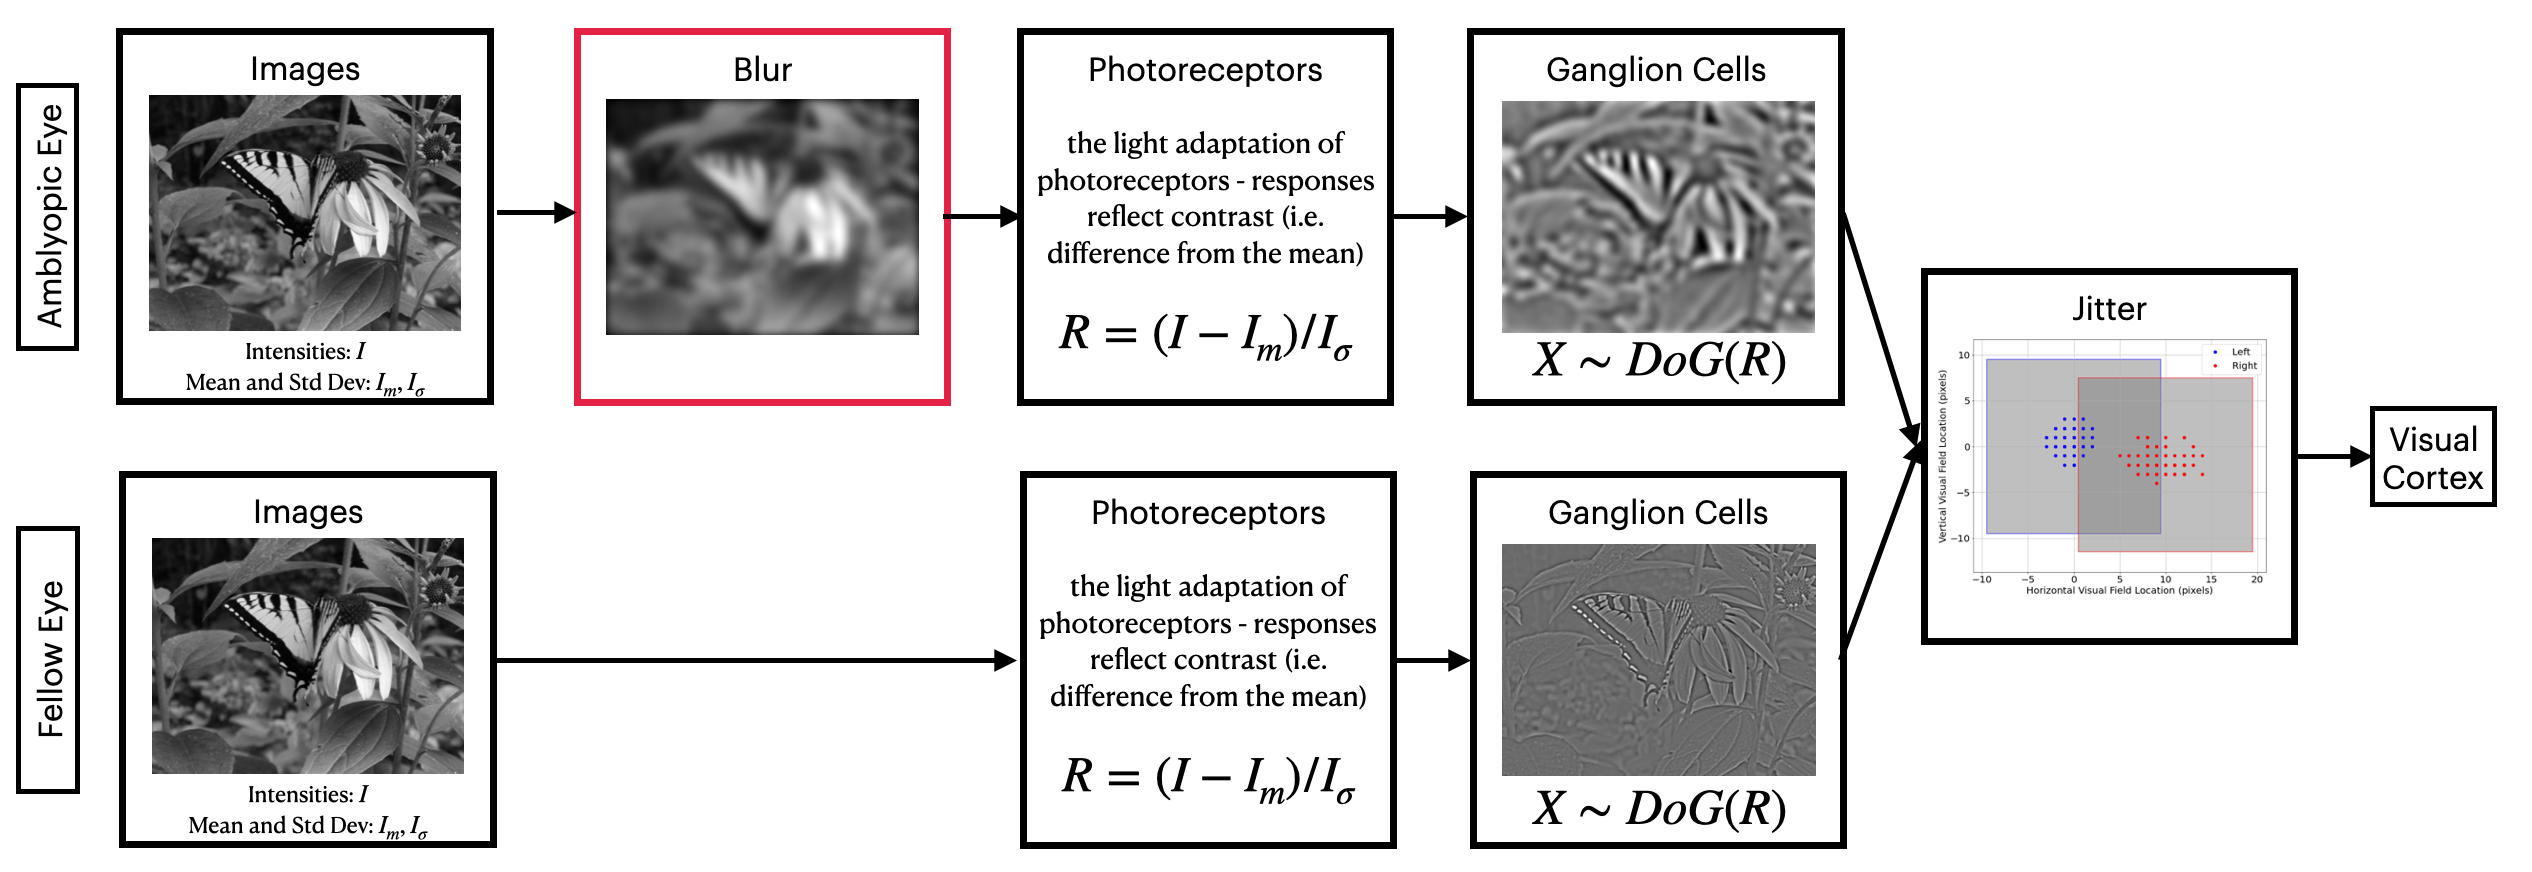

## Optical Correction 
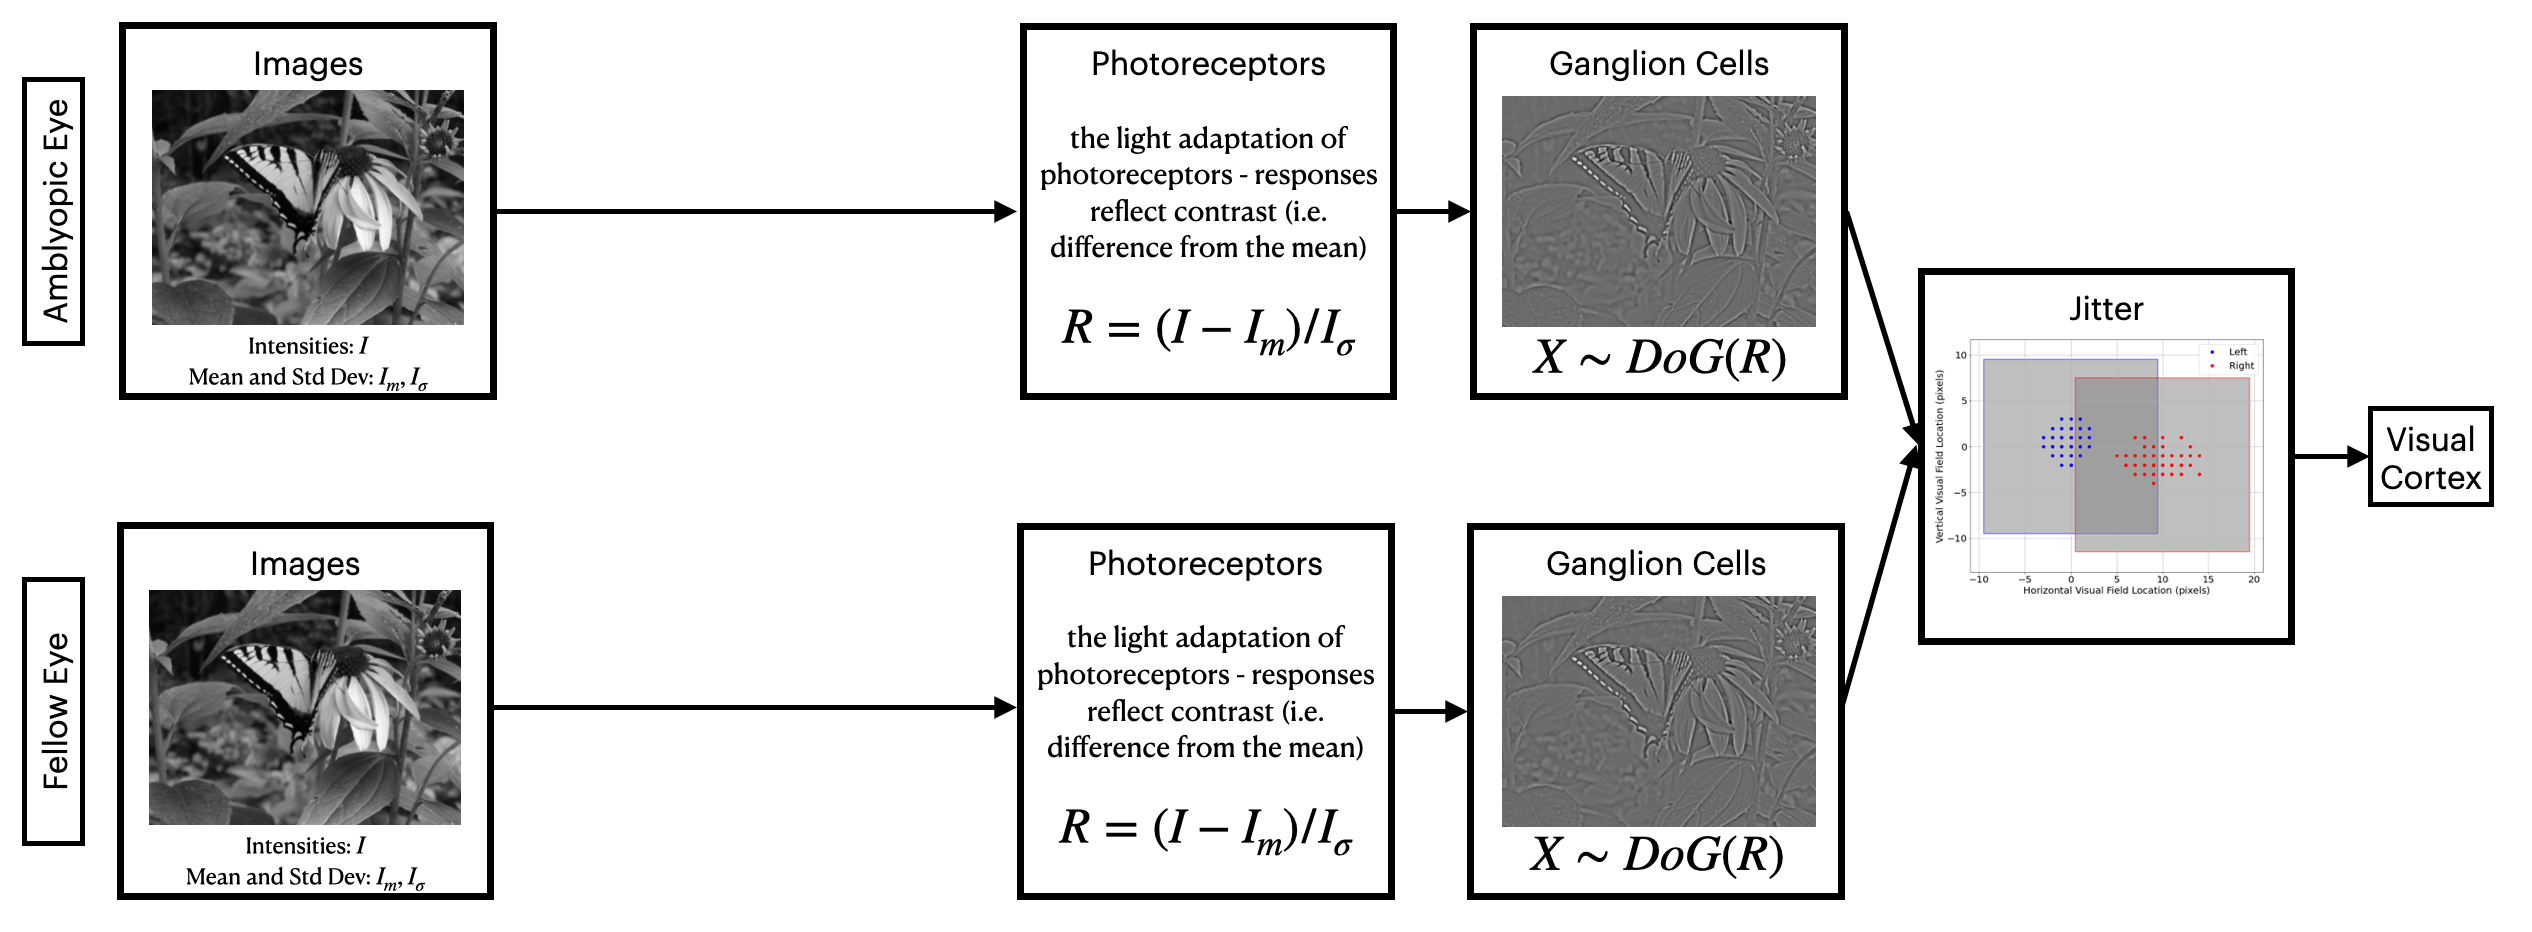

In [5]:
def deficit(blur=[2.5,-1],noise=[0.1,0.1],rf_size=19,
            eta=2e-6,
           number_of_neurons=10,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,
           total_time=8*day,
           save_interval=1*hour):

    dt=200*ms
    base_image_file='asdf/bbsk081604_all.asdf'
    print("Base Image File:",base_image_file)
    
    im=[]
    for b in blur:
        if b<0:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
        else:
            im+=[pi5.filtered_images(base_image_file,
                                    {'type':'blur','size':b},
                                    {'type':'norm'},
                                    {'type':'dog','sd1':1,'sd2':3},   
                                    verbose=False,
                                    )
                ]
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                                time_between_patterns=dt,
                                   rf_size=rf_size,
                                                sigma_r=0,
                                                sigma_c=0,
                                       verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],rf_size=rf_size,
                                                time_between_patterns=dt,
                                other_channel=pre1,
                                    mu_r=mu_r,mu_c=mu_c,
                                    sigma_r=sigma_r,sigma_c=sigma_c,
                                verbose=False)

    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])

    sigma=noise
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    sim=pn.simulation(total_time)
    sim.dt=dt

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi,
                            )

    return sim,[pre,post],[c]


@ray.remote
def run_one_deficit(params,run=True,overwrite=False):
    import plasticnet as pn
    noise,blur,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,total_time,sfname=(
                                params.noise,
                                params.blur,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.total_time,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 total_time=total_time,
                 noise=noise,blur=blur,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 


    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [6]:
def fix(noise=[0.1,0.1],rf_size=19,
           number_of_neurons=10,
           total_time=8*day,
           save_interval=1*hour,
            mu_c=0,sigma_c=0,    
            mu_r=0,sigma_r=0,        
           eta=2e-6):
    
    dt=200*ms
    im=[]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},   
                        verbose=False,
                        )
        ]
    im+=[pi5.filtered_images(base_image_file,
                        {'type':'norm'},
                        {'type':'dog','sd1':1,'sd2':3},
                        verbose=False,
                        )
        ]
                     
    
    
    pre1=pn.neurons.natural_images_with_jitter(im[0],
                                                time_between_patterns=dt,
                                        rf_size=rf_size,
                                        sigma_r=0,
                                        sigma_c=0,
                                        verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(im[1],
                                       rf_size=rf_size,
                                                time_between_patterns=dt,
                                       other_channel=pre1,
                                       mu_r=mu_r,mu_c=mu_c,
                                       sigma_r=sigma_r,sigma_c=sigma_c,
                                       verbose=False)
    
    


    pre1+=pn.neurons.process.add_noise_normal(0,noise[0])
    pre2+=pn.neurons.process.add_noise_normal(0,noise[1])

    pre=pre1+pre2

    post=default_post(number_of_neurons)
    c=default_bcm(pre,post)
    c.eta=eta

    save_interval=save_interval

    sim=pn.simulation(total_time)

    sim.dt=dt

    sim.monitor(post,['output'],save_interval)
    sim.monitor(c,['weights','theta'],save_interval)

    sim+=pn.grating_response(print_time=False,
                        k_mat=linspace(1,20,40)/19.0*pi)

    return sim,[pre,post],[c]

@ray.remote
def run_one_continuous_fix(params,run=True,overwrite=False):
    import plasticnet as pn
    count,eta,noise,mu_c,mu_r,sigma_c,sigma_r,number_of_neurons,sfname=(
                                params.count,
                                params.eta,
                                params.noise,
                                params.mu_c,
                                params.mu_r,
                                params.sigma_c,
                                params.sigma_r,
                                params.number_of_neurons,
                                params.sfname)
    
    if not overwrite and os.path.exists(sfname):
        return sfname
    
    seq=pn.Sequence()
    # deliberately use a standard deficit, with it's own eta and noise
    seq+=deficit(number_of_neurons=params.number_of_neurons,
                 mu_c=mu_c,sigma_c=sigma_c,
                mu_r=mu_r,sigma_r=sigma_r,) 

    seq+=fix(total_time=100*hour,
             save_interval=20*minute,number_of_neurons=params.number_of_neurons,
             eta=eta,noise=noise,mu_c=mu_c,sigma_c=sigma_c,
             mu_r=mu_r,sigma_r=sigma_r)

    if run:
        seq.run(display_hash=False)
        pn.save(sfname,seq) 
    
    return sfname
    

In [7]:
number_of_neurons=20
number_of_processes=8
ray.init(num_cpus=number_of_processes,ignore_reinit_error=True)

2025-06-10 14:37:28,042	INFO worker.py:1888 -- Started a local Ray instance.


Python version:,3.12.6
Ray version:,2.46.0


(pid=23809) Splikes version  0.1.5
(pid=23809) Plasticnet version  0.1.14
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit pid=23809) Base Image File: asdf/bbsk081604_all.asdf
(run_one_deficit

In [8]:
blur_mat=linspace(0,8,17)
blur_mat=linspace(0,2,5)
blur_mat

array([0. , 0.5, 1. , 1.5, 2. ])

In [9]:
mu_c_mat=linspace(0,20,9)
mu_c_mat

array([ 0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. ])

In [10]:
mu_c_mat=linspace(0,30,13)
mu_c_mat

array([ 0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. , 22.5, 25. ,
       27.5, 30. ])

In [11]:
func=run_one_deficit
count=0
open_eye_noise=0.0
sigma_c=1.0
mu_r=0.0
sigma_r=0.0

all_params=[]
for mu_count,mu_c in enumerate(mu_c_mat):
    for blur_count,blur in enumerate(blur_mat):
        sfname=f'{base_sim_dir}/deficit {number_of_neurons} neurons noise {open_eye_noise:.1f} blur {blur:.1f} mu_c {mu_c:.1f} sigma_c {sigma_c:.1f}.asdf'

        p=Struct()
        p.number_of_neurons=number_of_neurons
        p.sfname=sfname
        p.mu_c=mu_c
        p.sigma_c=sigma_c
        p.mu_r=mu_r
        p.sigma_r=sigma_r
        p.blur=[blur,-1]
        p.total_time=8*day*2   # default * 2
        p.noise=(open_eye_noise,open_eye_noise)
        all_params+=[p]

        
for a in all_params[:5]:
    print(a)
print("[....]")
for a in all_params[-5:]:
    print(a)

print(len(all_params))

{'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur': [0.0, -1], 'total_time': 1382400, 'noise': (0.0, 0.0)}
{'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.5 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur': [0.5, -1], 'total_time': 1382400, 'noise': (0.0, 0.0)}
{'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.0 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur': [1.0, -1], 'total_time': 1382400, 'noise': (0.0, 0.0)}
{'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.5 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur': [1.5, -1], 

In [12]:
# [params for params in all_params if params.blur[0]==0.5 and params.mu_c==10]

In [13]:
# %%time
# params=[params for params in all_params if params.blur[0]==0.5 and params.mu_c==10][0]
# result=func.remote(params,overwrite=True)
# sfname=ray.get(result)
# R=Results(params.sfname)

# μ1,μ2=R.μσ[0][0]
# σ1,σ2=R.μσ[1][0]
# print(μ1,μ2,σ1,σ2)

In [14]:
### premake the images
for params in tqdm(all_params):
    result=func.remote(params,run=False,overwrite=True)
    sfname=ray.get(result)
    print(sfname)

  0%|          | 0/65 [00:00<?, ?it/s]

sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.5 mu_c 0.0 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.0 mu_c 0.0 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.5 mu_c 0.0 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 2.0 mu_c 0.0 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.0 mu_c 2.5 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.5 mu_c 2.5 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.0 mu_c 2.5 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.5 mu_c 2.5 sigma_c 1.0.asdf
sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 2.0 mu_c 2.5 sigma_c

In [15]:
do_params=make_do_params(all_params,verbose=True)

65 sims
[{'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.0 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur': [0.0, -1], 'total_time': 1382400, 'noise': (0.0, 0.0)}, {'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 0.5 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur': [0.5, -1], 'total_time': 1382400, 'noise': (0.0, 0.0)}, {'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.0 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur': [1.0, -1], 'total_time': 1382400, 'noise': (0.0, 0.0)}, {'number_of_neurons': 20, 'sfname': 'sims-2025-06-04 dt mu_c sigma_c blur/deficit 20 neurons noise 0.0 blur 1.5 mu_c 0.0 sigma_c 1.0.asdf', 'mu_c': 0.0, 'sigma_c': 1.0, 'mu_r': 0.0, 'sigma_r': 0.0, 'blur':

In [16]:
results = [func.remote(p) for p in do_params]
sfnames=ray.get(results)

In [17]:
RR={}
for params in tqdm(all_params):
    RR[params.sfname]=Results(params.sfname)


  0%|          | 0/65 [00:00<?, ?it/s]

In [18]:
subResults={}
for params in tqdm(all_params):
    sfname=params.sfname
    R=RR[sfname]
    
    subR=Struct()
    subR.t=R.t/day
    t=subR.t
    
    subR.y=R.y
    subR.θ=R.θ

    idx1=R.sequence_index[0][1]
    
    subR.ODI=R.ODI
    subR.ORI=R.ORI
    subR.theta_mat=R.theta_mat
    subR.k_mat=R.k_mat
    subR.SF_Var=R.SF_Var
    subR.max_SF=R.max_SF
    subR.sfname=params.sfname
    subR.params=params
    subR.sequence_index=R.sequence_index
    subR.idx=[0]+[_[-1] for _ in R.sequence_index]
    subR.W=R.W[subR.idx,::]
    subR.ODI1=R.ODI[idx1,:]
    
    subResults[params.sfname]=subR


savevars(f'{base_sim_dir}/deficit_results.asdf',
         'subResults','mu_c_mat','blur_mat',
          )



  0%|          | 0/65 [00:00<?, ?it/s]

Saving sims-2025-06-04 dt mu_c sigma_c blur/deficit_results.asdf...done.


In [19]:
R.sequence_index

[(0, 384)]

0it [00:00, ?it/s]

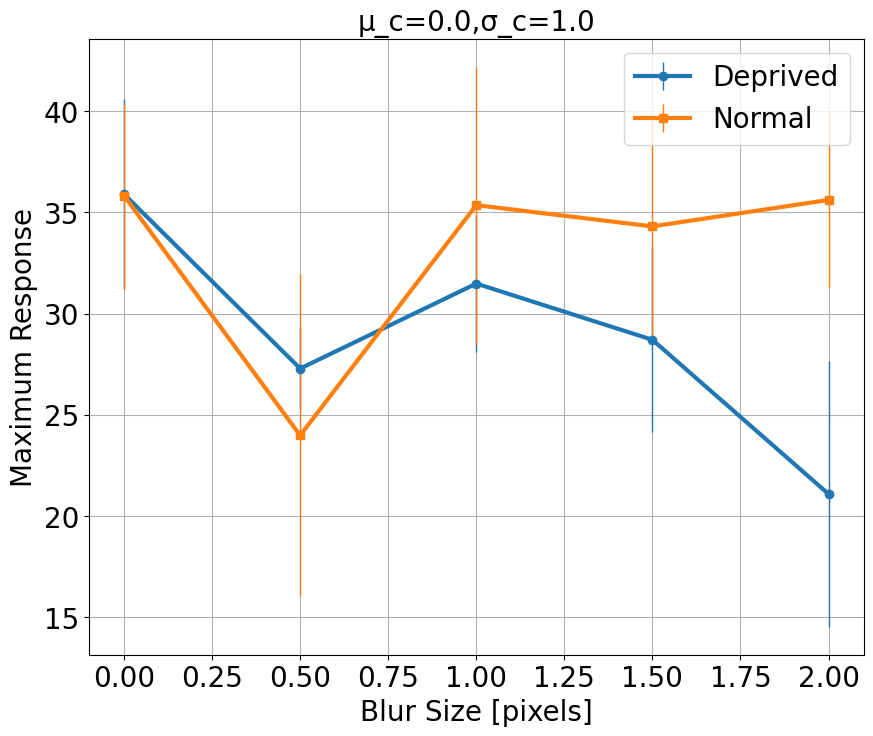

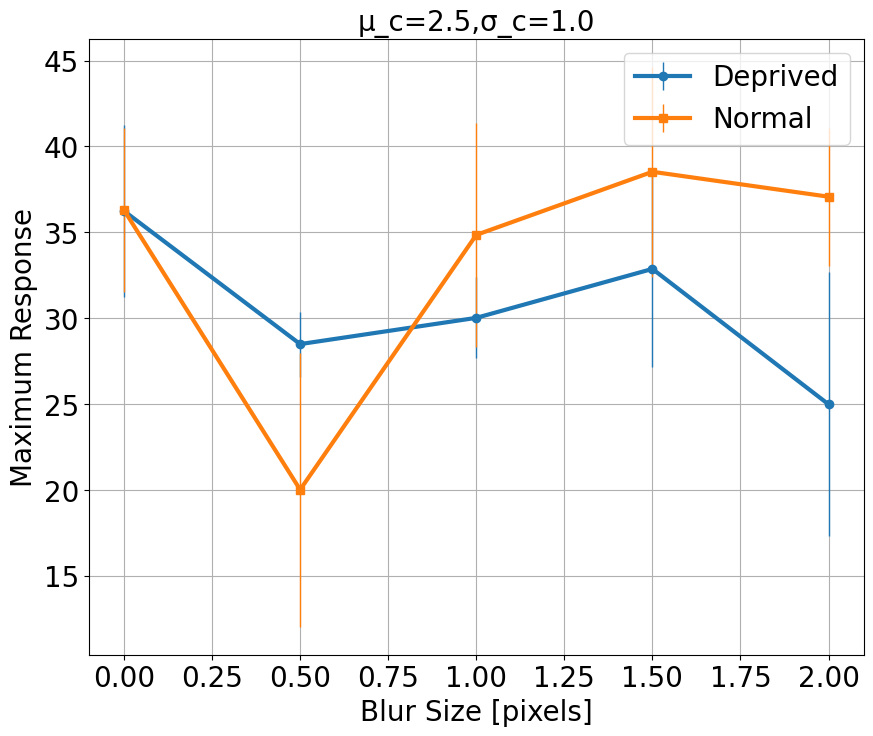

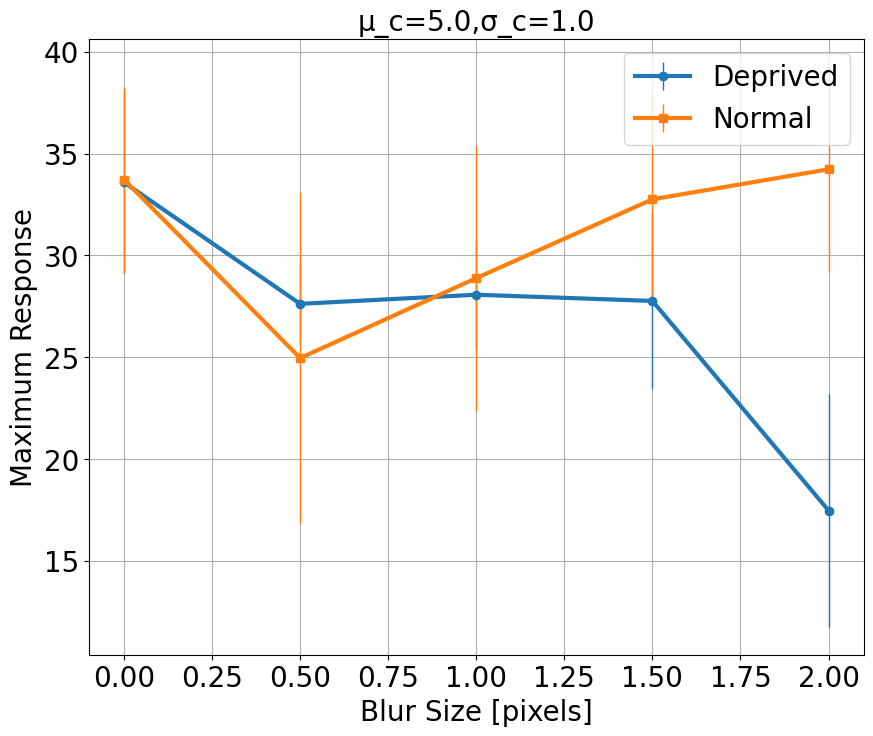

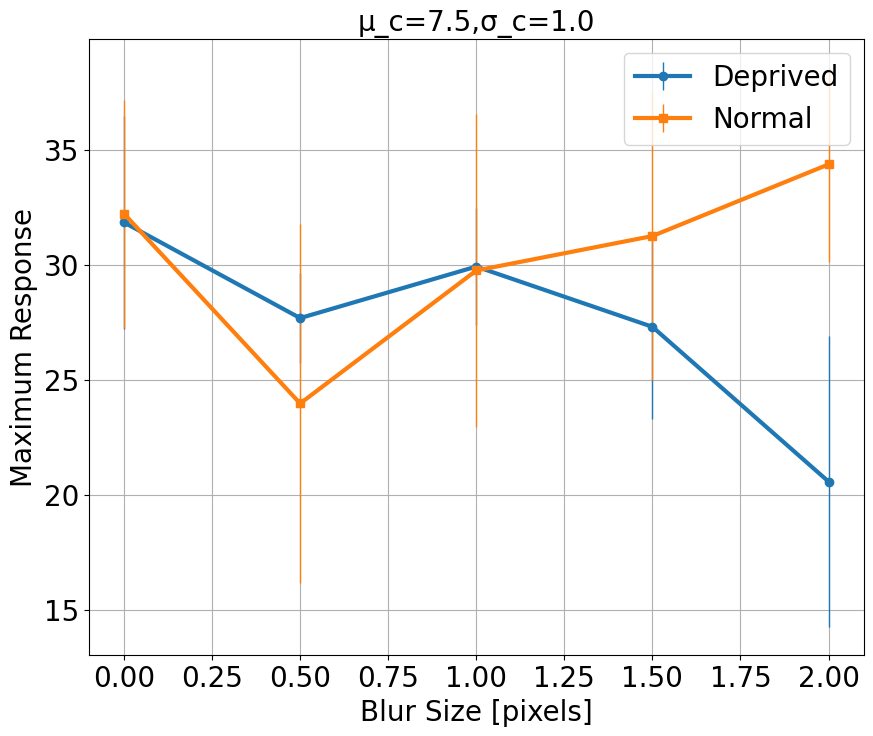

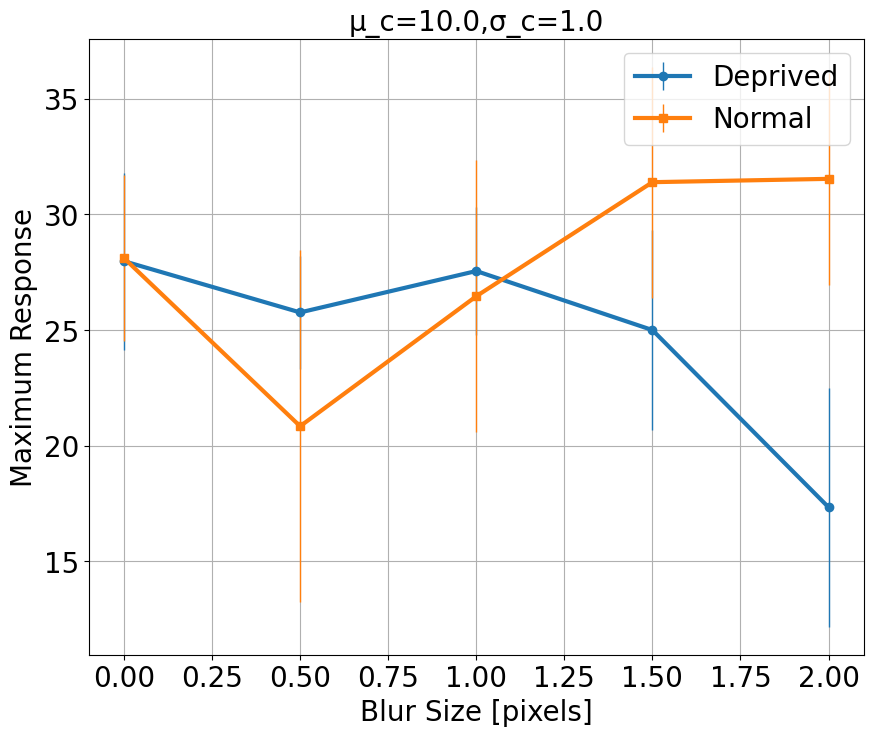

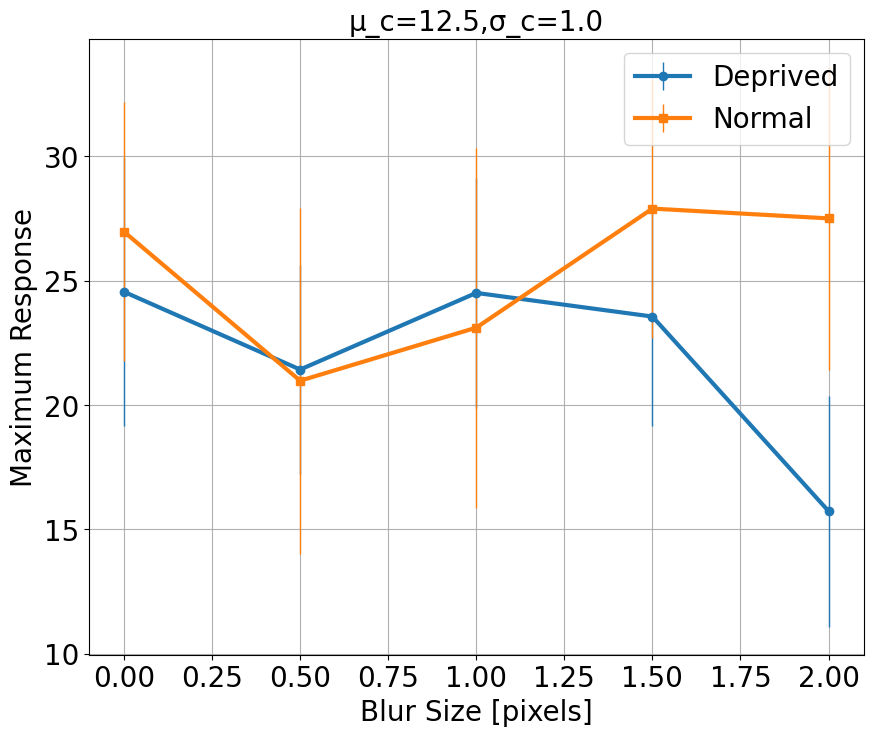

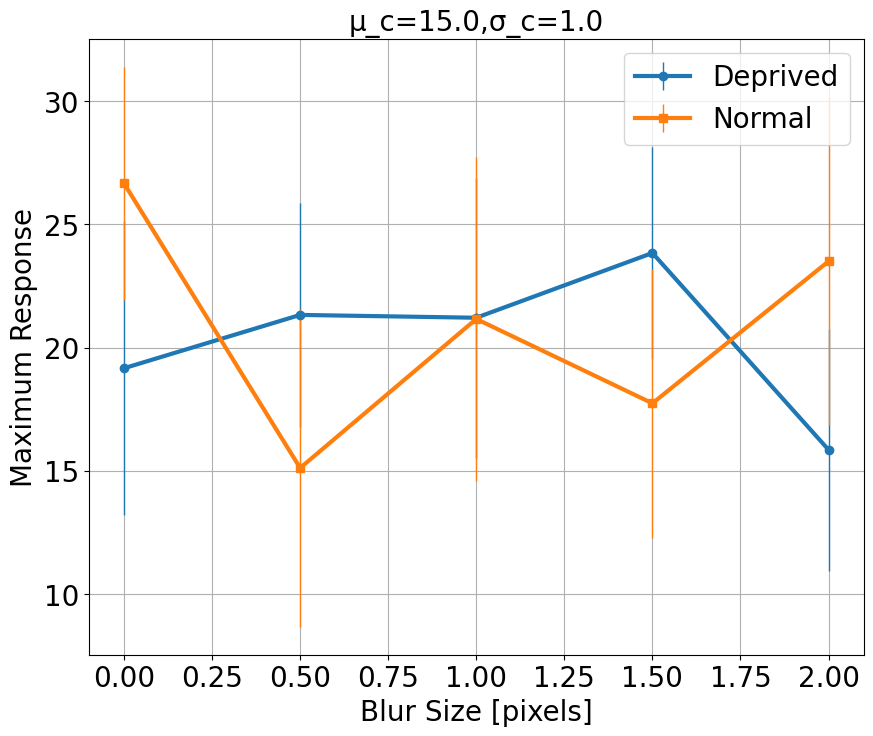

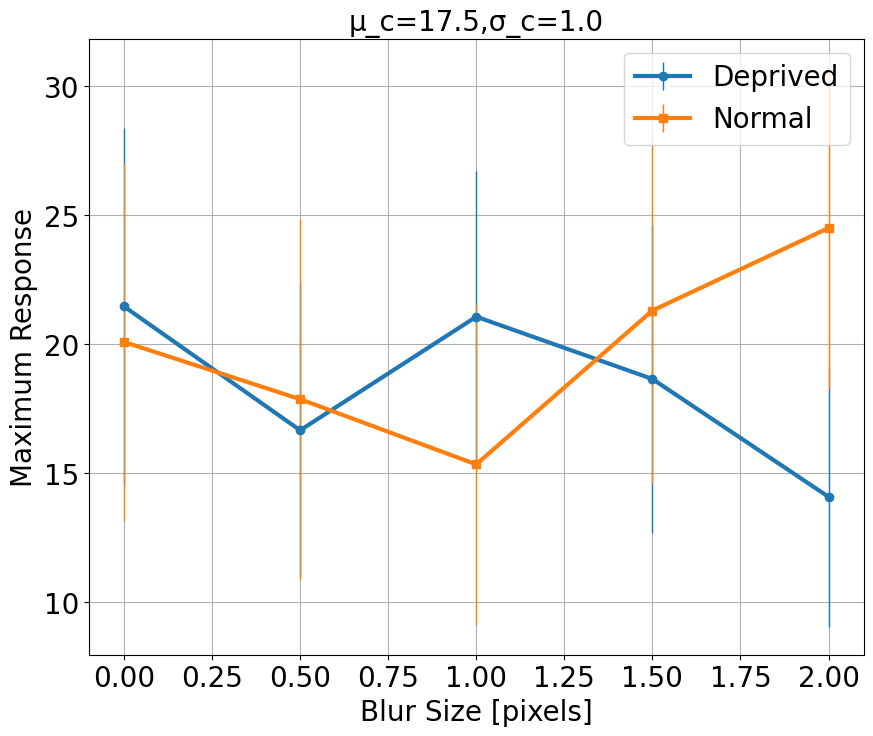

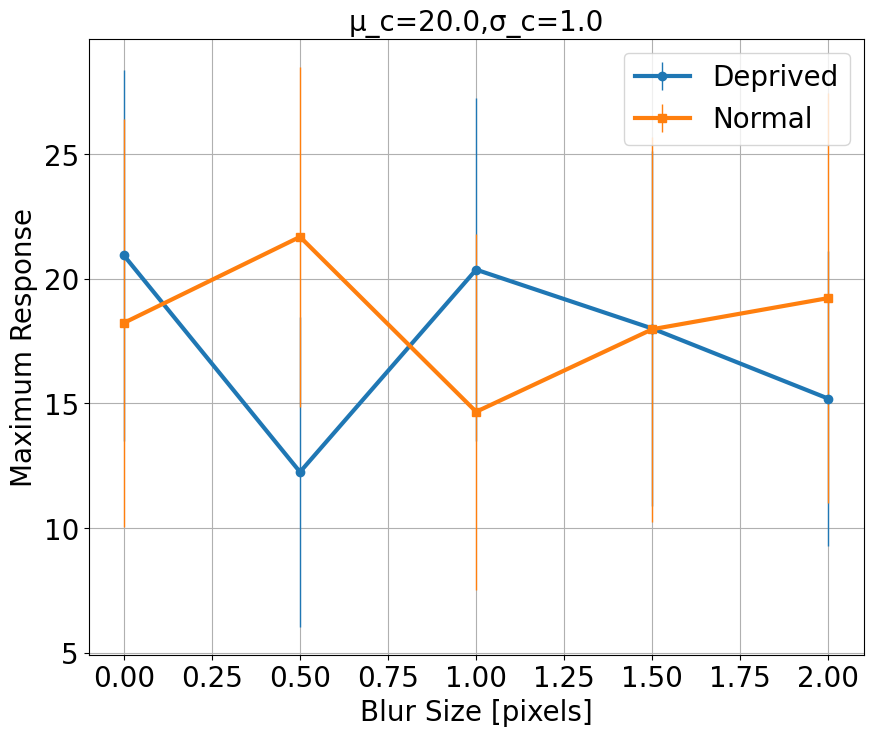

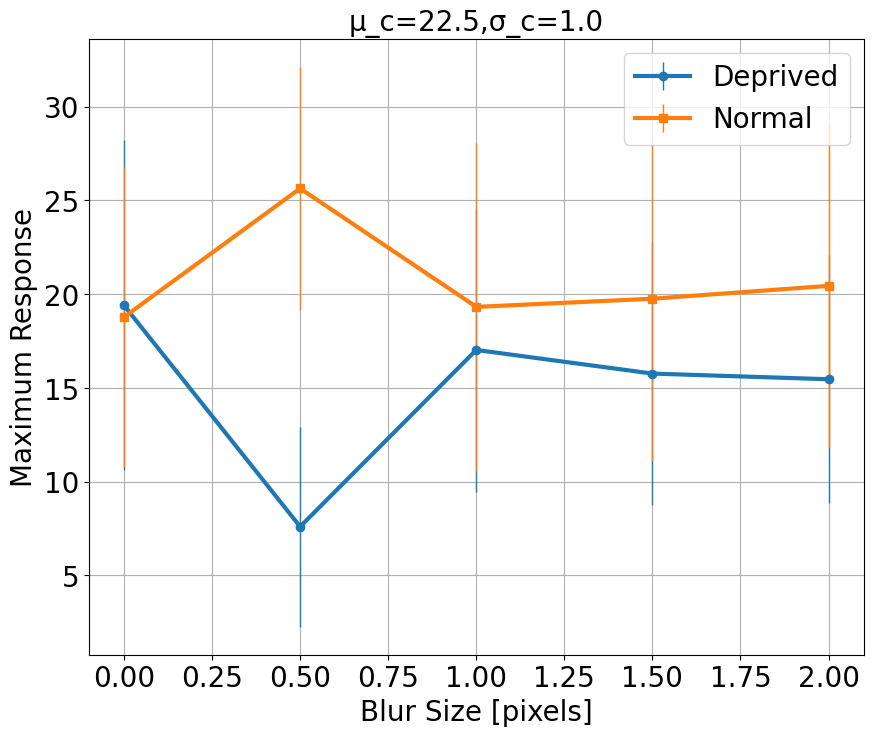

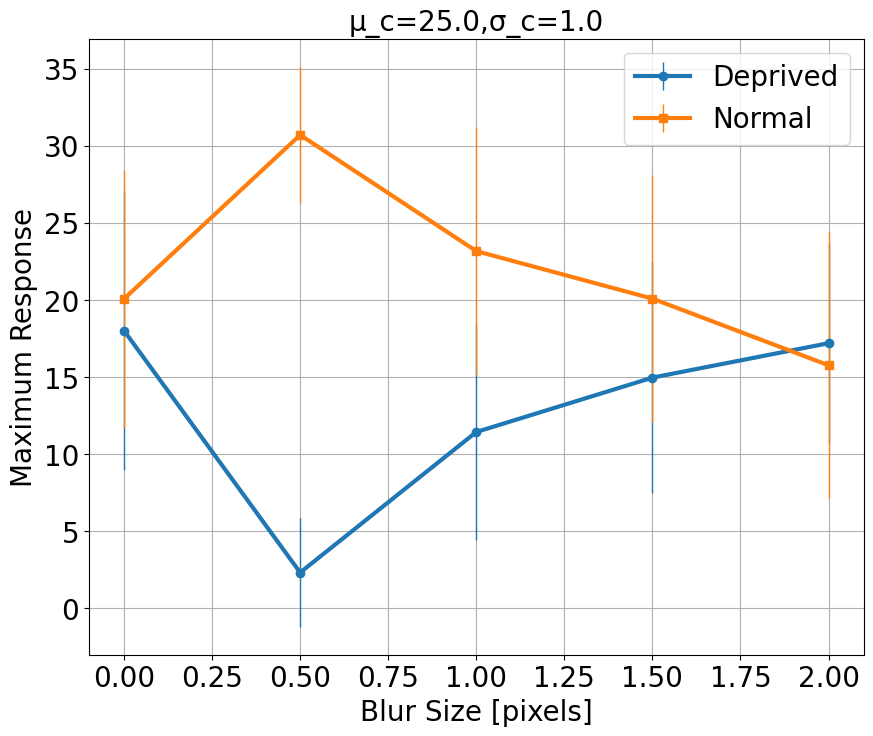

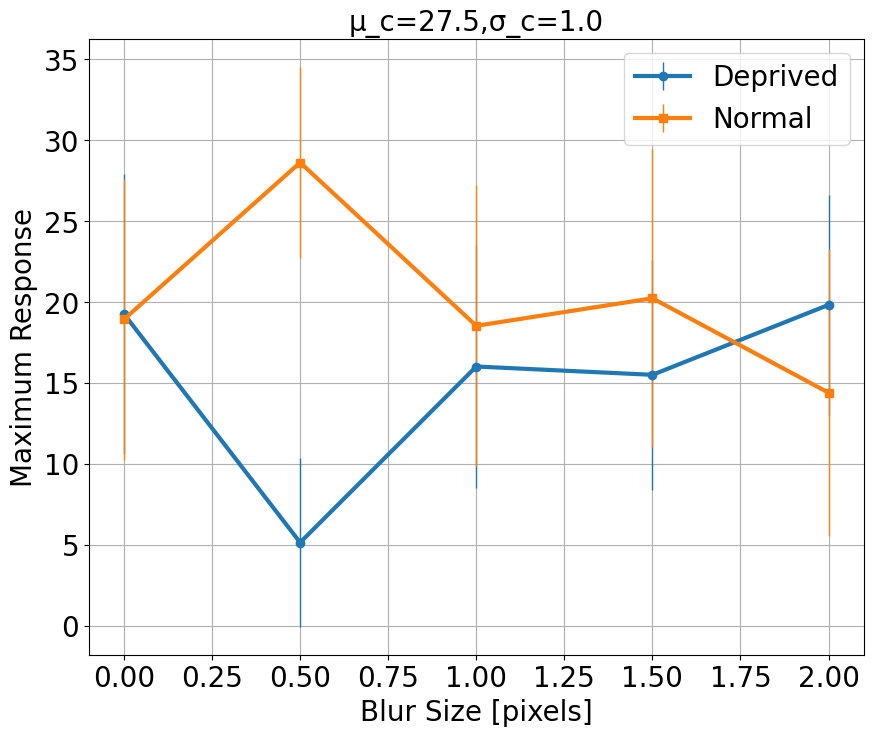

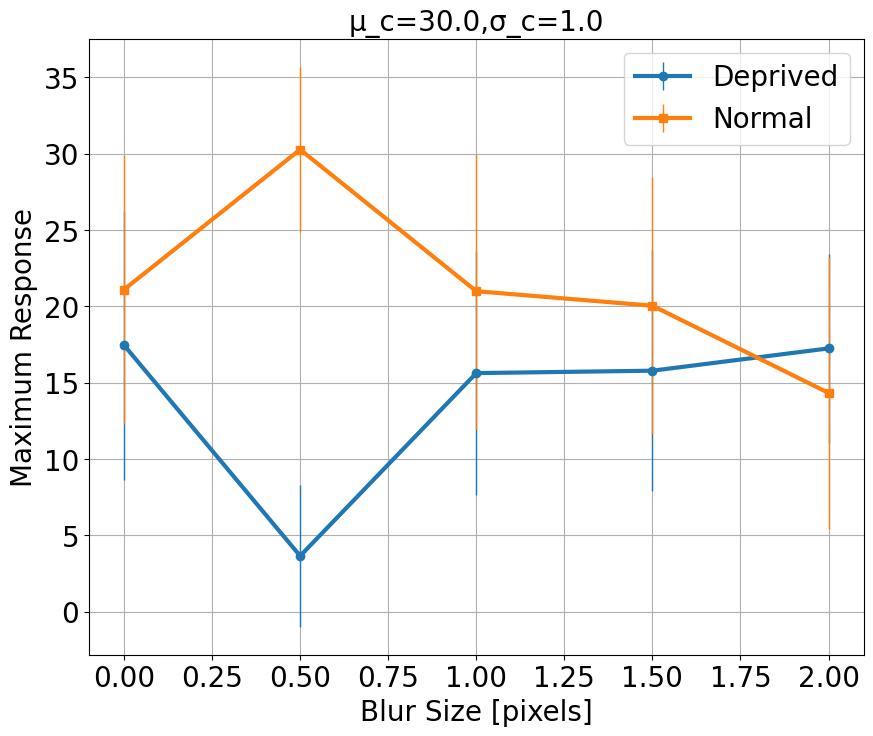

In [20]:
count=0
for mu_count,mu_c in tqdm(enumerate(mu_c_mat)):
    s=Storage()
    for blur_count,blur in enumerate(blur_mat):
        params=all_params[count]
        count+=1
        R=RR[params.sfname]
        blur=params.blur[0]
        μ1,μ2=R.μσ[0][0]
        σ1,σ2=R.μσ[1][0]

        s+=blur,μ1,μ2,σ1,σ2
    
    
    blur,μ1,μ2,σ1,σ2=s.arrays()
    
    figure()
    errorbar(blur,μ1,yerr=2*σ1,marker='o',elinewidth=1,label='Deprived')
    errorbar(blur,μ2,yerr=2*σ2,marker='s',elinewidth=1,label='Normal')
    xlabel('Blur Size [pixels]')
    ylabel('Maximum Response')
    title(f'μ_c={mu_c},σ_c={sigma_c}')
    legend()    



Text(0.5, 1.0, '$\\mu_c$')

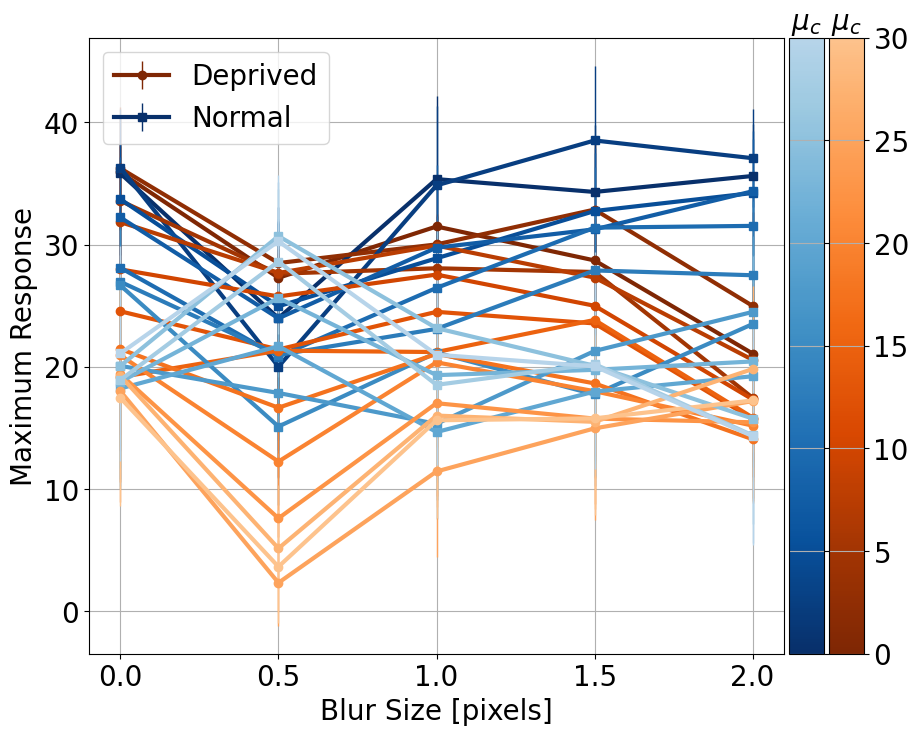

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

Blues2 = truncate_colormap(cm.Blues, 0.3, 1.0).reversed()
Oranges2 = truncate_colormap(cm.Oranges, 0.3, 1.0).reversed()

count=0
v=np.flip(linspace(0.3,1,len(mu_c_mat)))

for mu_count,mu_c in enumerate(mu_c_mat):
    s=Storage()
    for blur_count,blur in enumerate(blur_mat):
        params=all_params[count]
        count+=1
        R=RR[params.sfname]
        blur=params.blur[0]
        μ1,μ2=R.μσ[0][0]
        σ1,σ2=R.μσ[1][0]

        s+=blur,μ1,μ2,σ1,σ2
    
    
    blur,μ1,μ2,σ1,σ2=s.arrays()
    
    if mu_count==0:
        errorbar(blur,μ1,yerr=2*σ1,marker='o',elinewidth=1,label=f'Deprived',color=cm.Oranges(v[mu_count]))
        errorbar(blur,μ2,yerr=2*σ2,marker='s',elinewidth=1,label=f'Normal',color=cm.Blues(v[mu_count]))
    else:
        errorbar(blur,μ1,yerr=2*σ1,marker='o',elinewidth=1,color=cm.Oranges(v[mu_count]))
        errorbar(blur,μ2,yerr=2*σ2,marker='s',elinewidth=1,color=cm.Blues(v[mu_count]))
    xlabel('Blur Size [pixels]')
    ylabel('Maximum Response')

legend()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)   
ax_cb.grid(False)
ax_cb2 = divider.new_horizontal(size="5%", pad=0.05)    
ax_cb2.grid(False)
cb1 = mpl.colorbar.ColorbarBase(ax_cb, cmap=Blues2,norm=mpl.colors.Normalize(vmin=mu_c_mat[0], vmax=mu_c_mat[-1]),orientation='vertical')
cb2 = mpl.colorbar.ColorbarBase(ax_cb2, cmap=Oranges2,norm=mpl.colors.Normalize(vmin=mu_c_mat[0], vmax=mu_c_mat[-1]),orientation='vertical')
plt.gcf().add_axes(ax_cb)
ax_cb.grid(True)
ax_cb.set_yticklabels([])
ax_cb2.grid(True)
title(r'$\mu_c$')
plt.gcf().add_axes(ax_cb2)
title(r'$\mu_c$')


Text(0.5, 1.0, '$\\mu_c$')

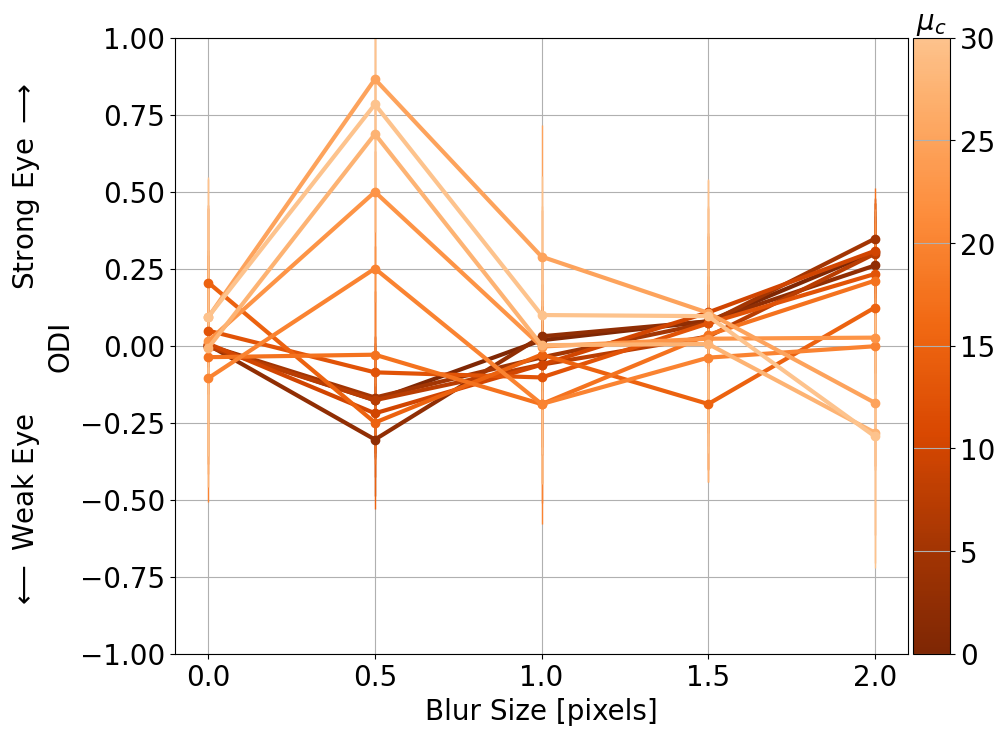

In [22]:
count=0
v=np.flip(linspace(0.3,1,len(mu_c_mat)))

for mu_count,mu_c in enumerate(mu_c_mat):
    s=Storage()
    for blur_count,blur in enumerate(blur_mat):
        params=all_params[count]
        count+=1
        R=RR[params.sfname]
        blur=params.blur[0]
        μ,σ=μσ(R.ODI[-1])

        s+=blur,μ,σ
    
    
    blur,μ,σ=s.arrays()
    errorbar(blur,μ,yerr=2*σ,marker='o',elinewidth=1,color=cm.Oranges(v[mu_count]))    
    xlabel('Blur Size [pixels]')
    ylabel(r'$\longleftarrow$ Weak Eye              Strong Eye $\longrightarrow$'+"\nODI")
    ylim([-1,1])

divider = make_axes_locatable(plt.gca())
ax_cb2 = divider.new_horizontal(size="5%", pad=0.05)    
ax_cb2.grid(False)
cb2 = mpl.colorbar.ColorbarBase(ax_cb2, cmap=Oranges2,norm=mpl.colors.Normalize(vmin=mu_c_mat[0], vmax=mu_c_mat[-1]),orientation='vertical')
ax_cb2.grid(True)
plt.gcf().add_axes(ax_cb2)
title(r'$\mu_c$')


In [23]:
R.ODI[-1]

array([-0.9847343 , -0.98272003, -0.87611697, -0.91968468, -0.9744628 ,
       -0.98832939,  0.97779955, -0.93763096, -0.9683989 ,  0.9709689 ,
       -0.98534248,  0.99005319,  0.95654318,  0.98324912,  0.82967906,
        0.8673292 , -0.98655801, -0.96873705, -0.9238292 , -0.97341347])

Text(0.5, 1.0, '$\\mu_c$')

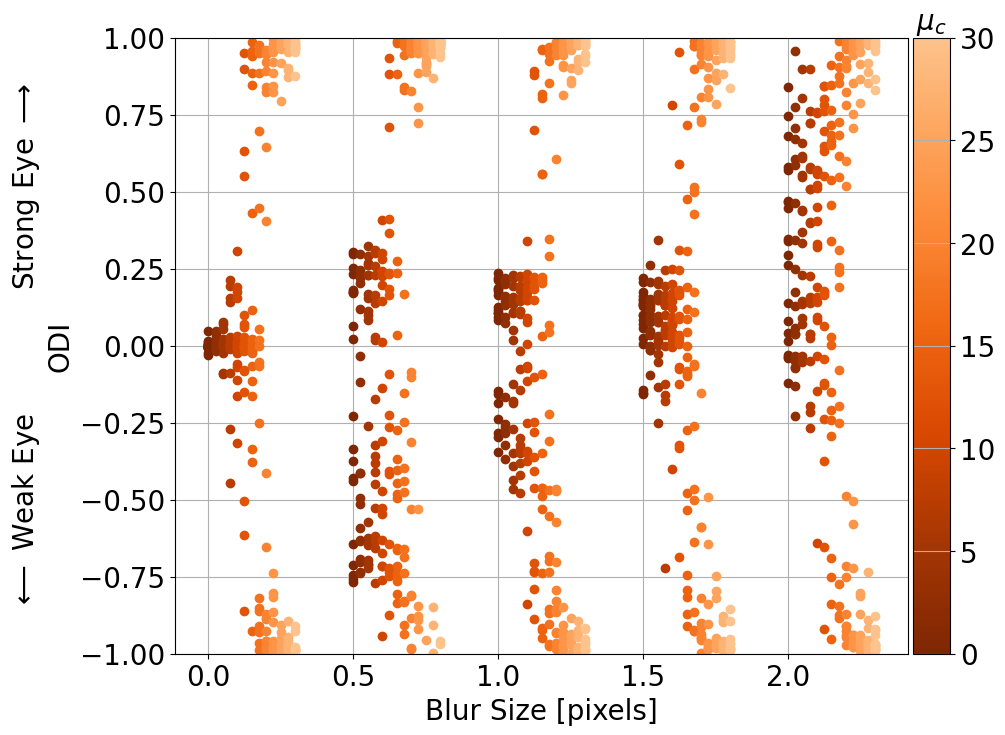

In [24]:
count=0
v=np.flip(linspace(0.3,1,len(mu_c_mat)))

for mu_count,mu_c in enumerate(mu_c_mat):
    s=Storage()
    for blur_count,blur in enumerate(blur_mat):
        params=all_params[count]
        count+=1
        R=RR[params.sfname]
        blur=params.blur[0]    

        plot(blur*ones(params.number_of_neurons)+.2*mu_c/20,R.ODI[-1],'o',color=cm.Oranges(v[mu_count]))

        
xlabel('Blur Size [pixels]')
ylabel(r'$\longleftarrow$ Weak Eye              Strong Eye $\longrightarrow$'+"\nODI")
ylim([-1,1])

divider = make_axes_locatable(plt.gca())
ax_cb2 = divider.new_horizontal(size="5%", pad=0.05)    
ax_cb2.grid(False)
cb2 = mpl.colorbar.ColorbarBase(ax_cb2, cmap=Oranges2,norm=mpl.colors.Normalize(vmin=mu_c_mat[0], vmax=mu_c_mat[-1]),orientation='vertical')
ax_cb2.grid(True)
plt.gcf().add_axes(ax_cb2)
title(r'$\mu_c$')
